# 02 — Baseline Model: TF-IDF + Logistic Regression

## Contexto

Antes de treinar modelos complexos como o BERT, é boa prática estabelecer um **modelo baseline** —
um modelo simples que serve de ponto de referência. Se o modelo avançado não conseguir superar
o baseline de forma clara, algo está errado.

Neste notebook, treinamos um pipeline clássico de NLP:
- **TF-IDF** (*Term Frequency–Inverse Document Frequency*): representa cada artigo como um vetor
  de pesos numéricos, onde palavras raras e informativas têm maior peso
- **Logistic Regression**: classificador linear, rápido e interpretável, muito usado como baseline
  em tarefas de classificação de texto

## Dados

Os dados utilizados provêm do dataset **FakeNewsNet**, já pré-processados e divididos na fase anterior:

| Split | Ficheiro |
|-------|----------|
| Treino | `data/processed/fakenewsnet/train.csv` |
| Validação | `data/processed/fakenewsnet/val.csv` |
| Teste | `data/processed/fakenewsnet/test.csv` |

A coluna de input é `input_text` (título + corpo do artigo concatenados) e o target é `label`
(0 = Fake, 1 = Real).

## Objetivo

Obter métricas de referência — em particular o **F1-score no conjunto de teste** — que servirão
de comparação direta com o modelo BERT fine-tuned desenvolvido a seguir.

## Estrutura do Notebook

1. Carregar dados
2. Preparar X e y
3. Vectorização com TF-IDF
4. Treinar Logistic Regression
5. Avaliação no conjunto de validação
6. Avaliação no conjunto de teste
7. Confusion Matrix
8. Guardar métricas em `results/metrics/results_baseline.json`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import sys
sys.path.insert(0, str(Path("..").resolve()))
from src.FKNWS.utils.get_logger import get_logger

logger = get_logger("baseline_model")
logger.info("Imports OK")

2026-03-31 16:51:56,067 | INFO | baseline_model | Imports OK


## 1. Carregar Dados

In [2]:
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "fakenewsnet"

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

logger.info(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nColunas: {list(train_df.columns)}")
print(f"\nDistribuição labels (train):\n{train_df['label'].value_counts()}")

2026-03-31 16:52:10,810 | INFO | baseline_model | Train: 336 | Val: 43 | Test: 43


Train: 336 | Val: 43 | Test: 43

Colunas: ['id', 'title_clean', 'text_clean', 'input_text', 'publish_date', 'label', 'source']

Distribuição labels (train):
label
1    168
0    168
Name: count, dtype: int64


## 2. Preparar X e y

In [3]:
# Remover nulos no input_text (segurança)
train_df = train_df.dropna(subset=["input_text"])
val_df   = val_df.dropna(subset=["input_text"])
test_df  = test_df.dropna(subset=["input_text"])

X_train, y_train = train_df["input_text"], train_df["label"]
X_val,   y_val   = val_df["input_text"],   val_df["label"]
X_test,  y_test  = test_df["input_text"],  test_df["label"]

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

X_train: (336,) | X_val: (43,) | X_test: (43,)


## 3. TF-IDF Vectorização

In [4]:
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
    sublinear_tf=True     # aplica log na frequência
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

logger.info(f"TF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF features: {X_train_tfidf.shape[1]}")

2026-03-31 16:57:40,963 | INFO | baseline_model | TF-IDF matrix shape: (336, 44040)


TF-IDF features: 44040


## 4. Treinar Logistic Regression

In [5]:
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)
logger.info("Logistic Regression treinada!")
print("Modelo treinado!")

2026-03-31 16:58:10,463 | INFO | baseline_model | Logistic Regression treinada!


Modelo treinado!


## 5. Avaliação — Validação

In [6]:
y_val_pred = lr_model.predict(X_val_tfidf)

val_metrics = {
    "accuracy":  round(accuracy_score(y_val, y_val_pred), 4),
    "precision": round(precision_score(y_val, y_val_pred), 4),
    "recall":    round(recall_score(y_val, y_val_pred), 4),
    "f1":        round(f1_score(y_val, y_val_pred), 4),
}

print("=== VALIDAÇÃO ===")
for k, v in val_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print("\nClassification Report (Val):")
print(classification_report(y_val, y_val_pred, target_names=["Fake", "Real"]))

=== VALIDAÇÃO ===
  accuracy    : 0.4651
  precision   : 0.4762
  recall      : 0.4545
  f1          : 0.4651

Classification Report (Val):
              precision    recall  f1-score   support

        Fake       0.45      0.48      0.47        21
        Real       0.48      0.45      0.47        22

    accuracy                           0.47        43
   macro avg       0.47      0.47      0.47        43
weighted avg       0.47      0.47      0.47        43



## 6. Avaliação — Teste

In [7]:
y_test_pred = lr_model.predict(X_test_tfidf)

test_metrics = {
    "accuracy":  round(accuracy_score(y_test, y_test_pred), 4),
    "precision": round(precision_score(y_test, y_test_pred), 4),
    "recall":    round(recall_score(y_test, y_test_pred), 4),
    "f1":        round(f1_score(y_test, y_test_pred), 4),
}

print("=== TESTE ===")
for k, v in test_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=["Fake", "Real"]))

=== TESTE ===
  accuracy    : 0.3023
  precision   : 0.3448
  recall      : 0.4762
  f1          : 0.4000

Classification Report (Test):
              precision    recall  f1-score   support

        Fake       0.21      0.14      0.17        22
        Real       0.34      0.48      0.40        21

    accuracy                           0.30        43
   macro avg       0.28      0.31      0.28        43
weighted avg       0.28      0.30      0.28        43



## 7. Confusion Matrix

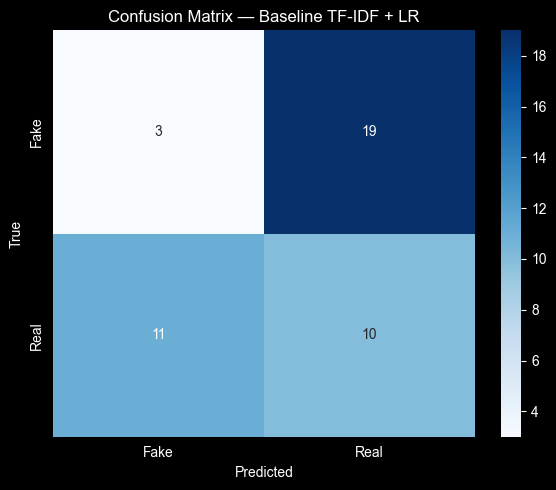

Guardada em results/figures/baseline_confusion_matrix.png


In [8]:
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"],
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Baseline TF-IDF + LR")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_confusion_matrix.png", dpi=150)
plt.show()
print(f"Guardada em results/figures/baseline_confusion_matrix.png")

## 8. Guardar Métricas

In [9]:
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

results = {
    "model": "baseline_tfidf_lr",
    "val": val_metrics,
    "test": test_metrics
}

with open(METRICS_DIR / "results_baseline.json", "w") as f:
    json.dump(results, f, indent=2)

logger.info(f"Métricas guardadas: {results}")
print(f"Métricas guardadas em results/metrics/results_baseline.json")
print(f"\n F1 no TESTE: {test_metrics['f1']:.4f}")

2026-03-31 17:08:59,877 | INFO | baseline_model | Métricas guardadas: {'model': 'baseline_tfidf_lr', 'val': {'accuracy': 0.4651, 'precision': 0.4762, 'recall': 0.4545, 'f1': 0.4651}, 'test': {'accuracy': 0.3023, 'precision': 0.3448, 'recall': 0.4762, 'f1': 0.4}}


Métricas guardadas em results/metrics/results_baseline.json

 F1 no TESTE: 0.4000


## Resumo

| Métrica       | Validação | Teste  |
|---------------|-----------|--------|
| Accuracy      | 0.4651    | 0.3023 |
| Precision     | 0.4762    | 0.3448 |
| Recall        | 0.4545    | 0.4762 |
| **F1**        | **0.4651**| **0.4000** |

> Baseline TF-IDF + Logistic Regression treinado com 336 exemplos (FakeNewsNet).
> O F1 de **0.40 no teste** é o nosso **ponto de referência** para comparar com o BERT.
> Resultado próximo de classificação aleatória (0.50), motivando a estratégia de
> transfer learning em cascata: pré-fine-tuning no LIAR → fine-tuning no FakeNewsNet.